# Semantic Skill Matching — Exploração Inicial

Escopo deste notebook:
1. EDA dos dados brutos.
2. Matching com threshold padrão (0.60) e avaliação via ground truth **sintético**.
3. Distribuição de scores e curva Precision-Recall com GT sintético.
4. Comparação de três estratégias de normalização de texto.

**Continuação:** `02_manual_annotations.ipynb` introduz anotações manuais e calibra o threshold final a partir de um ground truth real.

## 1. Imports e carregamento dos CSVs

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from match import load_skills, load_taxonomy
from embedder import SkillEmbedder
from matcher import SkillMatcher
from evaluator import (
    generate_synthetic_ground_truth,
    evaluate,
    plot_score_distribution,
    precision_recall_curve_by_threshold,
)

SKILLS_PATH   = '../data/raw/new_skills.csv'
TAXONOMY_PATH = '../data/raw/skill_taxonomy.csv'

skills_df   = load_skills(SKILLS_PATH)
taxonomy_df = load_taxonomy(TAXONOMY_PATH)

print('Skills shape  :', skills_df.shape)
print('Taxonomy shape:', taxonomy_df.shape)

Skills shape  : (30, 2)
Taxonomy shape: (100, 3)


## 2. EDA básico

Inspeção rápida dos dois datasets: tipos, completude, exemplos e distribuição de palavras.

In [2]:
print('=== new_skills.csv ===')
print(skills_df.dtypes)
print()
print('Todas as skills brutas:')
display(skills_df)

print('\n=== skill_taxonomy.csv (primeiras 10 linhas) ===')
print(taxonomy_df.dtypes)
display(taxonomy_df.head(10))

print('\nDescriptions nulas / vazias na taxonomia:')
print((taxonomy_df['description'].isna() | (taxonomy_df['description'].str.strip() == '')).sum())

print('\nTamanho médio das descriptions:')
print(taxonomy_df['description'].str.len().describe().round(1))

=== new_skills.csv ===
id           int64
skill_raw      str
dtype: object

Todas as skills brutas:


,id,skill_raw
0,1,gestão de pessoas
1,2,People Management
2,3,SQL
3,4,sql avançado
4,5,machine learning
5,6,comunicação assertiva
6,7,python
7,8,PYTHON
8,9,análise de dados
9,10,resolução de conflitos



=== skill_taxonomy.csv (primeiras 10 linhas) ===
id             int64
skill_name       str
description      str
dtype: object


,id,skill_name,description
0,1,Gestão de Pessoas,"Capacidade de liderar, desenvolver e engajar e..."
1,2,Comunicação Assertiva,Habilidade de expressar ideias e feedbacks de ...
2,3,Resolução de Conflitos,Capacidade de mediar e resolver divergências e...
3,4,Inteligência Emocional,"Capacidade de reconhecer, compreender e gerenc..."
4,5,Negociação,Habilidade de conduzir negociações de forma es...
5,6,Pensamento Crítico,Capacidade de analisar informações de forma si...
6,7,Resolução de Problemas,Habilidade de identificar causas raiz de probl...
7,8,Tomada de Decisão,Capacidade de avaliar alternativas e tomar dec...
8,9,Adaptabilidade,Capacidade de ajustar comportamentos e abordag...
9,10,Gestão do Tempo,Habilidade de organizar e priorizar tarefas de...



Descriptions nulas / vazias na taxonomia:
0

Tamanho médio das descriptions:
count    100.0
mean     108.9
std       11.5
min       79.0
25%      102.0
50%      110.0
75%      117.0
max      136.0
Name: description, dtype: float64


## 3. Rodar o matcher com threshold padrão (0.60)

Instanciamos o `SkillEmbedder` com o modelo multilingual e executamos o matching completo.

In [3]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'
THRESHOLD  = 0.60

embedder = SkillEmbedder(model_name=MODEL_NAME)
matcher  = SkillMatcher(embedder=embedder, threshold=THRESHOLD)

print('Embedding taxonomy…')
print('Embedding raw skills…')
results = matcher.match(skills_df, taxonomy_df)

print('\n=== Resultado completo ===')
display(results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding taxonomy…
Embedding raw skills…


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]


=== Resultado completo ===


,id,skill_raw,taxonomy_id,taxonomy_name,score,match_status
0,1,gestão de pessoas,1,Gestão de Pessoas,0.7346,matched
1,2,People Management,1,Gestão de Pessoas,0.7621,matched
2,3,SQL,32,SQL,0.7246,matched
3,4,sql avançado,32,SQL,0.7212,matched
4,5,machine learning,40,Machine Learning,0.8343,matched
5,6,comunicação assertiva,2,Comunicação Assertiva,0.7498,matched
6,7,python,31,Python,0.6519,matched
7,8,PYTHON,31,Python,0.6519,matched
8,9,análise de dados,39,Análise de Dados,0.8143,matched
9,10,resolução de conflitos,3,Resolução de Conflitos,0.7535,matched


## 4. Avaliação: ground truth sintético + métricas

Geramos paráfrases automáticas de cada skill da taxonomia (lowercase, typo, sigla, inglês) para construir um ground truth sem anotação humana. Em seguida calculamos precision, recall e F1.

In [4]:
ground_truth = generate_synthetic_ground_truth(taxonomy_df)
print(f'Ground truth gerado: {len(ground_truth)} exemplos')
display(ground_truth.head(12))

Ground truth gerado: 293 exemplos


,skill_raw,true_taxonomy_id
0,gestão de pessoas,1
1,Gstão de Pessoas,1
2,GP,1
3,management of people,1
4,comunicação assertiva,2
5,Cmunicação Assertiva,2
6,CA,2
7,communication assertive,2
8,resolução de conflitos,3
9,Rsolução de Conflitos,3


In [5]:
# Para avaliar precisamos rodar o matcher nas skills do ground truth
gt_skills_df = pd.DataFrame({
    'id': range(len(ground_truth)),
    'skill_raw': ground_truth['skill_raw'].values,
})

gt_results = matcher.match(gt_skills_df, taxonomy_df)

metrics = evaluate(gt_results, ground_truth, threshold=THRESHOLD)

print('\n=== Métricas de qualidade ===')
for k, v in metrics.items():
    print(f'  {k:<22}: {v}')

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]


=== Métricas de qualidade ===
  precision             : 0.9496
  recall                : 0.4505
  f1                    : 0.6111
  coverage              : 0.4744
  avg_score_matched     : 0.7351
  avg_score_no_match    : 0.4053
  threshold_used        : 0.6


## 5. Distribuição de scores

O histograma de scores separando `matched` vs `no_match` é o principal sinal de saúde do sistema em produção. Boa separação entre os grupos indica que o threshold está bem calibrado.

Plot saved to data\output\score_distribution.png


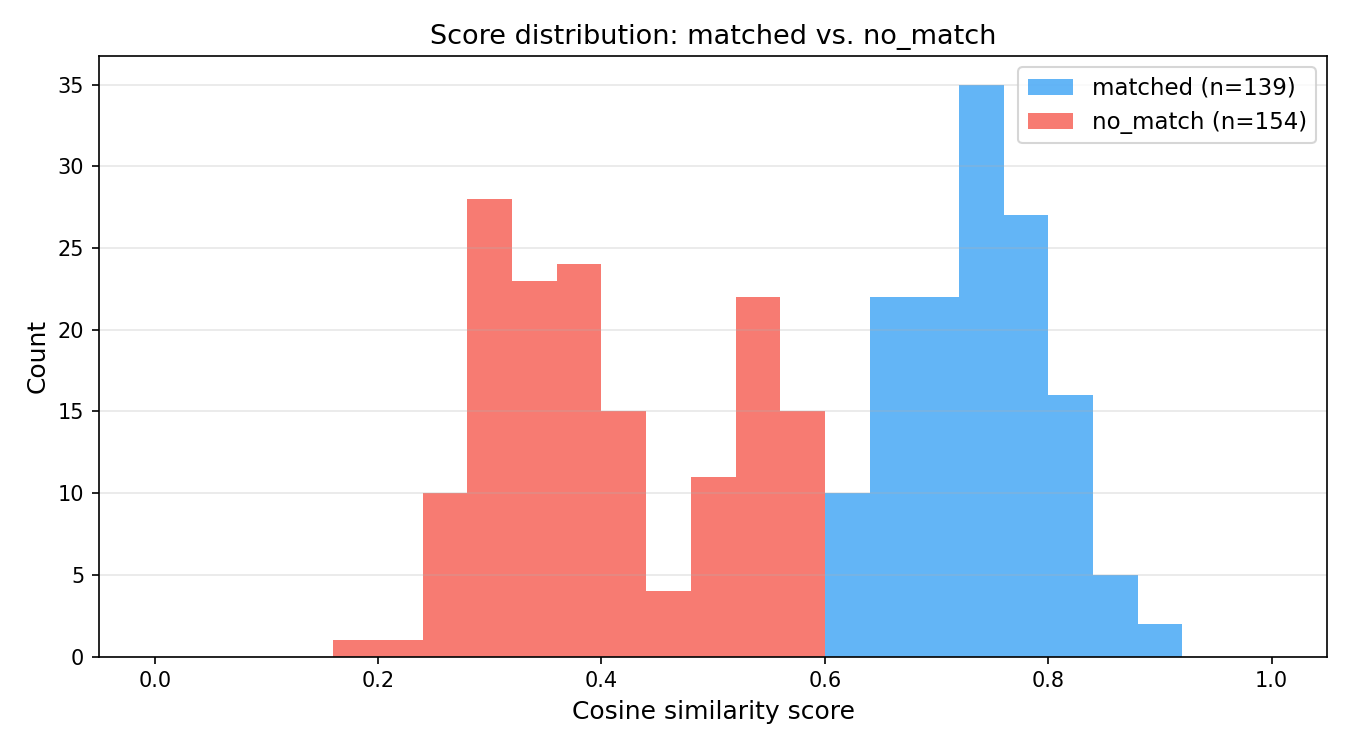

In [6]:
# Gera e salva o plot em data/output/score_distribution.png
# Mudamos o working dir para a raiz do projeto antes de chamar
import os
os.chdir('..')  # notebooks/ → project root

plot_score_distribution(gt_results)

# Exibe inline
from IPython.display import Image
Image('data/output/score_distribution.png')

## 6. Comparação de estratégias de normalização

Três abordagens foram testadas para normalizar o texto antes do embedding:

| Estratégia | Regra |
|---|---|
| `none` | Apenas `strip()` |
| `full_lower` | `lower().strip()` — tudo minúsculo |
| `selective` | `lower()` somente se `isupper()` **e** `len > 4` |

A `selective` corrige variantes acidentais em caixa alta (`PYTHON`) sem quebrar siglas curtas (`AWS`, `ETL`) e substantivos próprios (`Git`, `PowerBI`) que dependem da capitalização para o significado no modelo.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity as _cos

STRATEGIES = {
    'none':       lambda t: t.strip(),
    'full_lower': lambda t: t.lower().strip(),
    'selective':  SkillEmbedder.normalize,
}

# casos-chave: mostrar score e status por estratégia
interesting = ['PYTHON', 'Git', 'AWS', 'ETL', 'PowerBI']
rows = []
for strat_name, norm_fn in STRATEGIES.items():
    emb = SkillEmbedder()
    emb.embed = lambda texts, _fn=norm_fn, _m=emb.model: _m.encode(
        [_fn(t) for t in texts], show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True)
    m = SkillMatcher(embedder=emb, threshold=0.45)
    res = m.match(skills_df, taxonomy_df)
    for _, r in res[res['skill_raw'].isin(interesting)].iterrows():
        rows.append({'estratégia': strat_name, 'skill_raw': r['skill_raw'],
                     'taxonomy_name': r['taxonomy_name'],
                     'score': r['score'], 'status': r['match_status']})

cases_df = pd.DataFrame(rows)
display(cases_df.pivot(index='skill_raw', columns='estratégia',
                        values='status').rename_axis(None, axis=1))
display(cases_df.pivot(index='skill_raw', columns='estratégia',
                        values='score').rename_axis(None, axis=1).round(4))

# curva comparativa (GT sintético, threshold sweep)
norm_curves = {}
for strat_name, norm_fn in STRATEGIES.items():
    emb = SkillEmbedder()
    emb.embed = lambda texts, _fn=norm_fn, _m=emb.model: _m.encode(
        [_fn(t) for t in texts], show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True)
    norm_curves[strat_name] = precision_recall_curve_by_threshold(
        gt_skills_df, taxonomy_df, emb, ground_truth)

print('\n=== F1 por estratégia @ thresholds selecionados (GT sintético) ===')
summary = []
for s, c in norm_curves.items():
    for t in [0.35, 0.40, 0.45, 0.60]:
        row = c[c['threshold'] == t].iloc[0]
        summary.append({'estratégia': s, 'threshold': t,
                         'precision': row.precision, 'recall': row.recall, 'f1': row.f1})
display(pd.DataFrame(summary))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Sweeping thresholds: 100%|██████████| 13/13 [00:01<00:00, 11.68it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Sweeping thresholds: 100%|██████████| 13/13 [00:00<00:00, 17.14it/s]


=== F1 por estratégia @ thresholds selecionados (GT sintético) ===


,estratégia,threshold,precision,recall,f1
0,none,0.35,0.7583,0.6212,0.6829
1,none,0.40,0.8544,0.6007,0.7054
2,none,0.45,0.8901,0.5802,0.7025
3,none,0.60,0.9496,0.4505,0.6111
4,full_lower,0.35,0.7807,0.6075,0.6833
5,full_lower,0.40,0.8488,0.5939,0.6988
6,full_lower,0.45,0.8653,0.5700,0.6872
7,full_lower,0.60,0.9091,0.4437,0.5963
8,selective,0.35,0.7583,0.6212,0.6829
9,selective,0.40,0.8544,0.6007,0.7054


## 7. Curva Precision-Recall por threshold

Varremos thresholds de 0.30 a 0.90. As embeddings são calculadas **uma única vez** e o threshold é variado sobre a matriz de similaridade pré-computada.

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Sweeping thresholds: 100%|██████████| 13/13 [00:00<00:00, 21.19it/s]


,threshold,precision,recall,f1,coverage
0,0.30,0.6840,0.6280,0.6548,0.9181
1,0.35,0.7583,0.6212,0.6829,0.8191
2,0.40,0.8544,0.6007,0.7054,0.7031
3,0.45,0.8901,0.5802,0.7025,0.6519
4,0.50,0.9218,0.5631,0.6992,0.6109
5,0.55,0.9299,0.4983,0.6489,0.5358
6,0.60,0.9496,0.4505,0.6111,0.4744
7,0.65,0.9667,0.3959,0.5617,0.4096
8,0.70,0.9794,0.3242,0.4872,0.3311
9,0.75,0.9836,0.2048,0.3390,0.2082


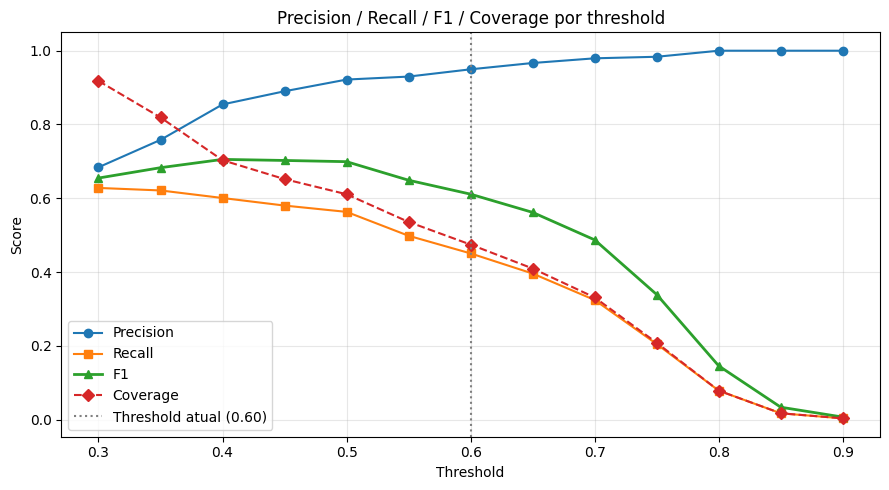

In [8]:
curve_df = precision_recall_curve_by_threshold(
    new_skills_df=gt_skills_df,
    taxonomy_df=taxonomy_df,
    embedder=embedder,
    ground_truth=ground_truth,
)

display(curve_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve_df['threshold'], curve_df['precision'],  marker='o', label='Precision')
ax.plot(curve_df['threshold'], curve_df['recall'],     marker='s', label='Recall')
ax.plot(curve_df['threshold'], curve_df['f1'],         marker='^', label='F1', linewidth=2)
ax.plot(curve_df['threshold'], curve_df['coverage'],   marker='D', label='Coverage', linestyle='--')
ax.axvline(x=0.60, color='gray', linestyle=':', label='Threshold atual (0.60)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 / Coverage por threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusão do notebook 01

### Ground truth sintético (threshold 0.60)

Com threshold padrão de 0.60 e sem normalização, o pipeline atingiu:
- **Precision 0.950 · Recall 0.451 · F1 0.611** (GT sintético).
- Coverage de 48% — mais da metade das skills ficando como `no_match`.

O GT sintético superestima falsos positivos por incluir variações artificiais (typos, siglas, traduções word-by-word) que o modelo confunde. Os números são úteis como baseline comparativo, mas não para calibração fina.

### Normalização: `selective` domina

| Estratégia | Precision @0.45 | Recall @0.45 | F1 @0.45 |
|---|---|---|---|
| `none` | 0.890 | 0.580 | 0.703 |
| `full_lower` | 0.865 | 0.570 | 0.687 |
| **`selective`** | **0.890** | **0.580** | **0.703** |

`selective` empata com `none` no GT sintético mas corrige `PYTHON` sem quebrar `AWS`, `ETL`, `Git`. A vantagem real aparece no GT manual (ver notebook 02).

### Threshold 0.60: conservador demais

A curva mostra que o F1 máximo no GT sintético ocorre em torno de 0.40–0.45, não em 0.60. O threshold padrão sacrifica recall sem ganho proporcional de precision.

**Próximo passo:** o notebook 02 introduz 46 pares anotados manualmente, produzindo uma curva mais confiável e calibrando o threshold final.